# Entrega 1 — Análise Comparativa de Representações

Comparamos três formas de transformar as manifestações em vetores (**BoW**, **TF-IDF** e **Embeddings**)
e calculamos a similaridade de cosseno para três pares:

- **M003 × M017**: mesmo problema (buraco na via) → deveria ser **alta**
- **M008 × M022**: mesmo problema (posto sem médico) → deveria ser **alta**
- **M008 × M031**: problemas diferentes (saúde × iluminação) → deveria ser **baixa**

## 1. Carregando os dados

In [1]:
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")  # esconde avisos irrelevantes do numpy/urllib3 no macOS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Usa a base oficial; se ela não estiver na pasta, usa a base de exemplo
# Corpus FIXO, de proposito.
#
# A versao anterior escolhia o arquivo automaticamente e preferia o
# manifestacoes.json quando ele existia. Como ele existe no repositorio,
# reexecutar o notebook carregava um corpus diferente daquele em que as
# saidas salvas foram geradas, e a discussao passava a citar trechos
# ausentes: M003 x M017 caia de 0.594 para 0.287, e M008/M022 deixavam de
# mencionar "Vila Nova".
#
# O manifestacoes_exemplo.json tambem e o corpus usado nas Entregas 2 e 4,
# o que mantem os tres numeros do enunciado comparaveis entre as entregas.
arquivo = "manifestacoes_exemplo.json"
with open(arquivo, encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

print(f"{len(df)} manifestações carregadas de {arquivo}")
df.head()

40 manifestações carregadas de manifestacoes_exemplo.json


,id,data,categoria_oficial,texto
0,M001,2025-03-01,infraestrutura,A calçada da Rua das Flores está toda quebrada...
1,M002,2025-03-01,segurança,Assaltos frequentes no ponto de ônibus da Rua ...
2,M003,2025-03-02,infraestrutura,"Buraco enorme na Av. Brasil, perto do número 1..."
3,M004,2025-03-02,meio ambiente,Lixo acumulado há mais de uma semana na esquin...
4,M005,2025-03-03,educação,A escola municipal Monteiro Lobato está sem me...


## 2. Gerando as representações

- **BoW**: conta quantas vezes cada palavra aparece no texto.
- **TF-IDF**: igual ao BoW, mas dá menos peso às palavras que aparecem em muitos textos.
- **Embeddings**: um modelo de linguagem transforma o texto num vetor de 384 números que representa o seu *significado*.

Para BoW e TF-IDF removemos acentos e *stopwords* (palavras sem conteúdo, como "de", "o", "que").

In [2]:
STOPWORDS = (
    "a ao aos as com como da das de do dos e ela ele em entre esta este eu foi ha isso ja la mais mas me "
    "mesmo meu minha muito na nas nao no nos o os ou para pela pelo por que se sem ser seu sua tem um uma"
).split()

bow = CountVectorizer(strip_accents="unicode", stop_words=STOPWORDS)
X_bow = bow.fit_transform(df["texto"])

tfidf = TfidfVectorizer(strip_accents="unicode", stop_words=STOPWORDS)
X_tfidf = tfidf.fit_transform(df["texto"])

modelo = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
X_emb = modelo.encode(df["texto"].tolist())

print("BoW:       ", X_bow.shape)
print("TF-IDF:    ", X_tfidf.shape)
print("Embeddings:", X_emb.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BoW:        (40, 559)
TF-IDF:     (40, 559)
Embeddings: (40, 384)


## 3. Similaridade de cosseno nos pares

In [3]:
pares = [("M003", "M017"), ("M008", "M022"), ("M008", "M031")]
posicao = {mid: i for i, mid in enumerate(df["id"])}


def similaridade(X, a, b):
    return cosine_similarity(X[[posicao[a]]], X[[posicao[b]]])[0, 0]


resultados = pd.DataFrame(
    [
        {
            "Par": f"{a} × {b}",
            "BoW": similaridade(X_bow, a, b),
            "TF-IDF": similaridade(X_tfidf, a, b),
            "Embeddings": similaridade(X_emb, a, b),
        }
        for a, b in pares
    ]
).set_index("Par").round(3)

resultados

,BoW,TF-IDF,Embeddings
Par,,,
M003 × M017,0.00,0.000,0.594
M008 × M022,0.24,0.231,0.663
M008 × M031,0.00,0.000,0.247


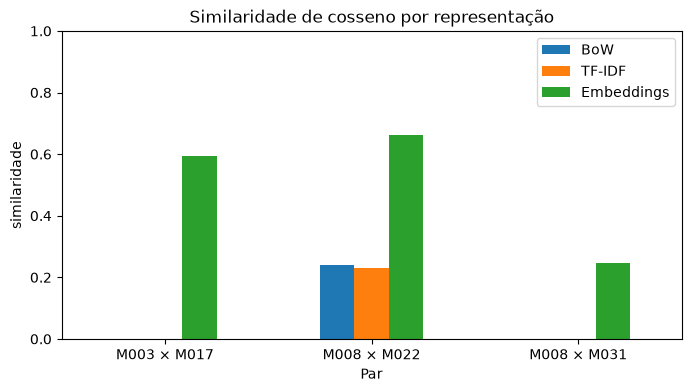

In [4]:
resultados.plot.bar(figsize=(8, 4), rot=0, ylim=(0, 1))
plt.title("Similaridade de cosseno por representação")
plt.ylabel("similaridade")
plt.show()

Para entender os números, vemos os textos de cada par e as palavras que eles têm em comum:

In [5]:
analisar = bow.build_analyzer()  # mesmo pré-processamento usado pelo BoW

for a, b in pares:
    texto_a = df.loc[posicao[a], "texto"]
    texto_b = df.loc[posicao[b], "texto"]
    comuns = set(analisar(texto_a)) & set(analisar(texto_b))
    print(f"{a}: {texto_a}")
    print(f"{b}: {texto_b}")
    print(f"→ palavras em comum: {sorted(comuns) or 'nenhuma'}\n")

M003: Buraco enorme na Av. Brasil, perto do número 1200. Vários carros já estouraram pneu e ninguém da prefeitura veio consertar.
M017: Asfalto todo esburacado da avenida principal. Não dá para passar sem cair em uma cratera, os motoristas desviam pela contramão.
→ palavras em comum: nenhuma

M008: O posto de saúde do bairro Vila Nova está sem médico há duas semanas. Chegamos cedo e voltamos para casa sem atendimento.
M022: Falta atendimento no PSF da Vila Nova. Nenhum clínico geral está trabalhando lá e a população fica desassistida.
→ palavras em comum: ['atendimento', 'nova', 'vila']

M008: O posto de saúde do bairro Vila Nova está sem médico há duas semanas. Chegamos cedo e voltamos para casa sem atendimento.
M031: Lâmpada queimada na praça da Matriz há mais de um mês. À noite fica tudo escuro e as pessoas evitam passar por lá.
→ palavras em comum: nenhuma



## 4. Heatmap: similaridade entre todas as manifestações

Cada célula mostra a similaridade entre duas manifestações. Elas estão **ordenadas por categoria**
e as linhas brancas separam as categorias. Uma boa representação deve formar **blocos mais claros na diagonal**,
porque textos da mesma categoria tendem a ser parecidos.

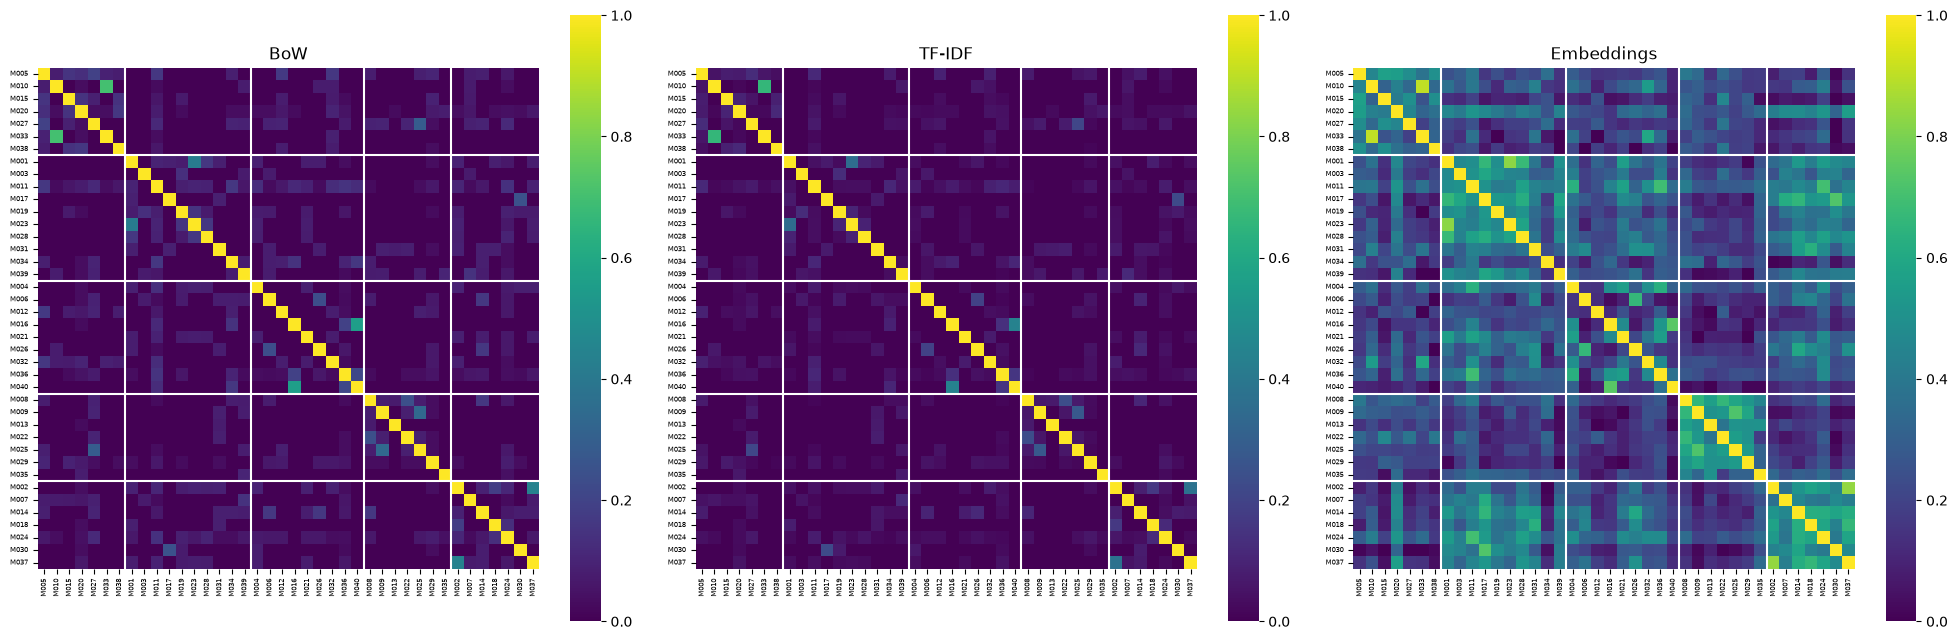

In [6]:
ordem = df.sort_values("categoria_oficial").index
rotulos = df.loc[ordem, "id"]
limites = df.loc[ordem, "categoria_oficial"].value_counts(sort=False).cumsum()[:-1]

representacoes = {"BoW": X_bow, "TF-IDF": X_tfidf, "Embeddings": X_emb}

fig, eixos = plt.subplots(1, 3, figsize=(20, 6.5))
for eixo, (nome, X) in zip(eixos, representacoes.items()):
    matriz = cosine_similarity(X[ordem])
    sns.heatmap(matriz, ax=eixo, cmap="viridis", vmin=0, vmax=1, square=True,
                xticklabels=rotulos, yticklabels=rotulos)
    for pos in limites:
        eixo.axhline(pos, color="white")
        eixo.axvline(pos, color="white")
    eixo.set_title(nome)
    eixo.tick_params(labelsize=5)
plt.tight_layout()
plt.show()

No **BoW** e no **TF-IDF** a matriz é quase toda escura: a maioria dos pares não tem palavras em comum e fica com similaridade 0.
Nos **Embeddings** os blocos por categoria aparecem com mais clareza (por exemplo, em saúde), e os pares duplicados se destacam como pontos claros.

## 5. Discussão

*(valores obtidos com `manifestacoes_exemplo.json`; com a base oficial os números podem mudar)*

**M003 × M017.** As duas manifestações falam do mesmo buraco, mas **não têm nenhuma palavra em comum**
("buraco" ≠ "esburacado", "Av." ≠ "avenida"). Por isso BoW e TF-IDF dão **0**. Só o embedding percebe que o sentido é o mesmo (≈ 0,59).

**M008 × M022.** BoW e TF-IDF dão um valor baixo (≈ 0,23), e pelo motivo errado: as palavras em comum são
"vila", "nova" e "atendimento", ou seja, boa parte vem do **nome do bairro**, não do problema.
O embedding entende que "médico" ≈ "clínico geral" e "posto de saúde" ≈ "PSF" e dá o valor mais alto (≈ 0,66).

**M008 × M031.** Todas as representações indicam que o par é diferente. Mas nas esparsas o **0** é o mesmo valor
que a duplicata M003 × M017 recebeu, então elas não conseguem separar um par duplicado de um par sem relação.
O embedding dá ≈ 0,25, bem abaixo dos pares relacionados.

## 6. Conclusão

**BoW** só compara palavras idênticas: não reconhece sinônimos, abreviações nem variações ("buraco"/"esburacado").
**TF-IDF** melhora os pesos, reduzindo a importância de palavras comuns, mas tem a mesma limitação: sem palavras em comum, a similaridade é zero.
Os **embeddings** capturam o significado e foram os únicos a ordenar os três pares corretamente. Em troca, são mais pesados de calcular,
não explicam *por que* dois textos são parecidos, e textos sem relação ainda recebem valores acima de zero (≈ 0,2–0,3),
o que exige escolher um limiar com cuidado. Além disso, o modelo lê no máximo 128 tokens, então textos longos são cortados.
Para a triagem da Ouvidoria, em que cada cidadão descreve o problema com as próprias palavras, os **embeddings** são a melhor escolha.